# 准备数据

In [1]:
import sys
sys.path.append('/home/hyd/research/vnpy_hub')
sys.path.append('/home/hyd/research/vnpy_hub/vnpy')

In [2]:
# 过滤Alphalens的warning
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [3]:
# 加载模块
import polars as pl

from vnpy.trader.constant import Interval

from vnpy.alpha import AlphaLab

In [4]:
# 创建数据中心
lab: AlphaLab = AlphaLab('./lab/all_stocks')

In [5]:
# 设置任务参数
name = "300_lgb"
index_symbol: str = "000300.SSE"
start: str = "2017-01-01"
end: str = "2025-08-01"
interval: Interval = Interval.DAILY
extended_days: int = 100

In [6]:
# 加载所有成分股代码
component_symbols: list[str] = lab.load_component_symbols(index_symbol, start, end)

# 特征计算

In [7]:
# 加载模块
from functools import partial

from vnpy.trader.constant import Interval

from vnpy.alpha.dataset import (
    AlphaDataset,
    process_drop_na,
    process_cs_norm
)
from vnpy.alpha.dataset.datasets.alpha_158 import Alpha158

In [8]:
# 加载成分股数据
df: pl.DataFrame = lab.load_bar_df(component_symbols, interval, start, end, extended_days)

In [9]:
# 设置数据时间段
train_period: tuple[str, str] = ("2017-01-01", "2021-12-31")
valid_period: tuple[str, str] = ("2022-01-01", "2023-12-31")
test_period: tuple[str, str] = ("2023-01-01", "2025-08-01")

In [10]:
# 创建数据集对象
dataset: AlphaDataset = Alpha158(
    df,
    train_period=train_period,
    valid_period=valid_period,
    test_period=test_period,
)

In [11]:
# 添加数据预处理器
dataset.add_processor("learn", partial(process_drop_na, names=["label"]))
dataset.add_processor("learn", partial(process_cs_norm, names=["label"], method="zscore"))

In [12]:
# 收集指数成分过滤器
filters: dict[str, list[str]] = lab.load_component_filters(index_symbol, start, end)

In [13]:
# 准备特征和标签数据
dataset.prepare_data(filters, max_workers=80)

2025-12-12 20:58:38 开始计算表达式因子特征


  1%|          | 1/158 [00:01<03:49,  1.46s/it]

Feature calculation kmid took: 0.015712499618530273 seconds | (close - open) / open


  1%|▏         | 2/158 [00:01<02:17,  1.13it/s]

Feature calculation klen took: 0.018467187881469727 seconds | (high - low) / open


...

Feature calculation imxd_20 took: 75.45621752738953 seconds | (ts_argmax(high, 20) - ts_argmin(low, 20)) / 20
Feature calculation imxd_60 took: 74.51630592346191 seconds | (ts_argmax(high, 60) - ts_argmin(low, 60)) / 60


100%|██████████| 158/158 [01:59<00:00,  1.33it/s]

Feature calculation imxd_30 took: 75.23291015625 seconds | (ts_argmax(high, 30) - ts_argmin(low, 30)) / 30


2025-12-12 21:00:40 开始筛选成分股数据


100%|██████████| 591/591 [00:05<00:00, 105.37it/s]


In [14]:
# 特征表现分析
# dataset.show_feature_performance("rsv_5")

In [15]:
# 保存到文件缓存
lab.save_dataset(name, dataset, format='pkl')

# 模型训练

In [16]:
# 加载模块
import numpy as np

from vnpy.alpha import Segment, AlphaDataset, AlphaModel

from vnpy.alpha.model.models.lgb_model import LgbModel

In [17]:
# 从文件缓存加载
dataset: AlphaDataset = lab.load_dataset(name)

In [18]:
dataset.raw_df.write_csv("lgb.csv")

In [19]:
# 创建模型对象
model: AlphaModel = LgbModel(seed=42)

In [20]:
# 使用数据集训练模型
model.fit(dataset)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.029598 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 32578
[LightGBM] [Info] Number of data points in the train set: 365097, number of used features: 158
[LightGBM] [Info] Start training from score 0.000000
[1]	train's l2: 0.995132	valid's l2: 0.996643
Training until validation scores don't improve for 50 rounds
[2]	train's l2: 0.993878	valid's l2: 0.996695
[3]	train's l2: 0.992732	valid's l2: 0.996662
[4]	train's l2: 0.991585	valid's l2: 0.996695
[5]	train's l2: 0.99049	valid's l2: 0.996734
[6]	train's l2: 0.989599	valid's l2: 0.996747
[7]	train's l2: 0.988675	valid's l2: 0.996788
[8]	train's l2: 0.987918	valid's l2: 0.996861
[9]	train's l2: 0.987162	valid's l2: 0.996894
[10]	train's l2: 0.986432	valid's l2: 0.996841
[11]	train's l2: 0.985774	valid's l2: 0.9969
[12]	train's l2: 0.985067	valid's l2: 0.997013
[13]	train's l2: 0.984365	valid's l2: 0.99

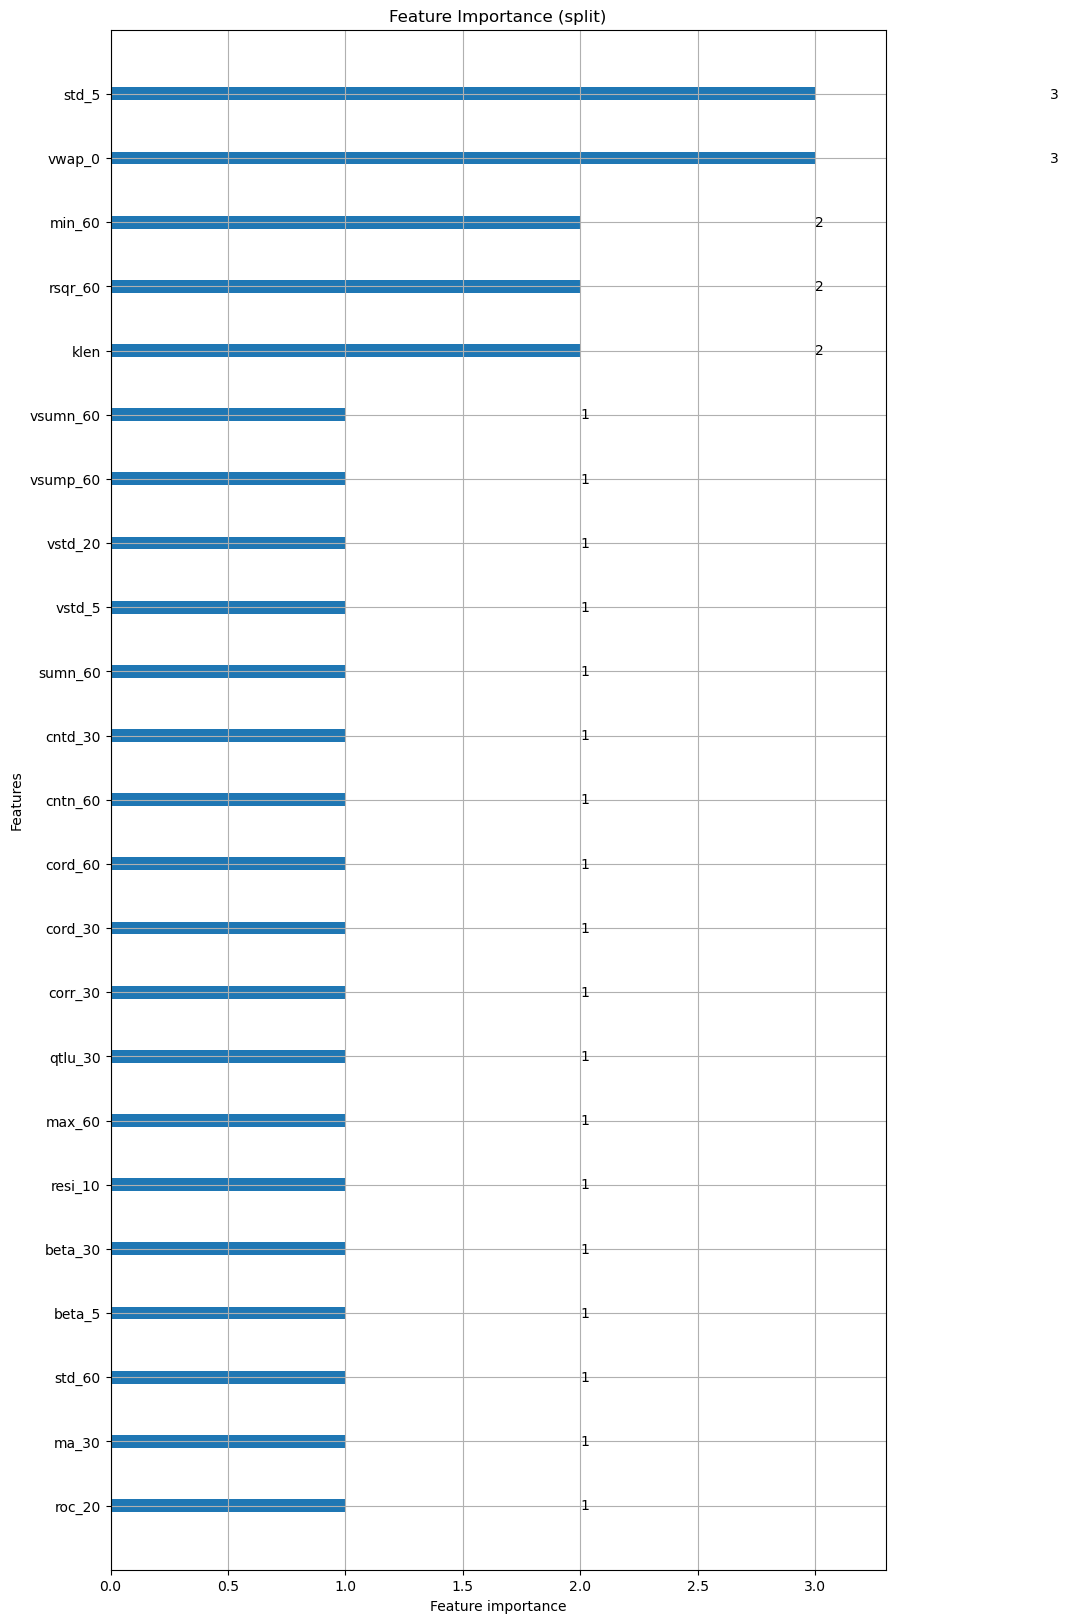

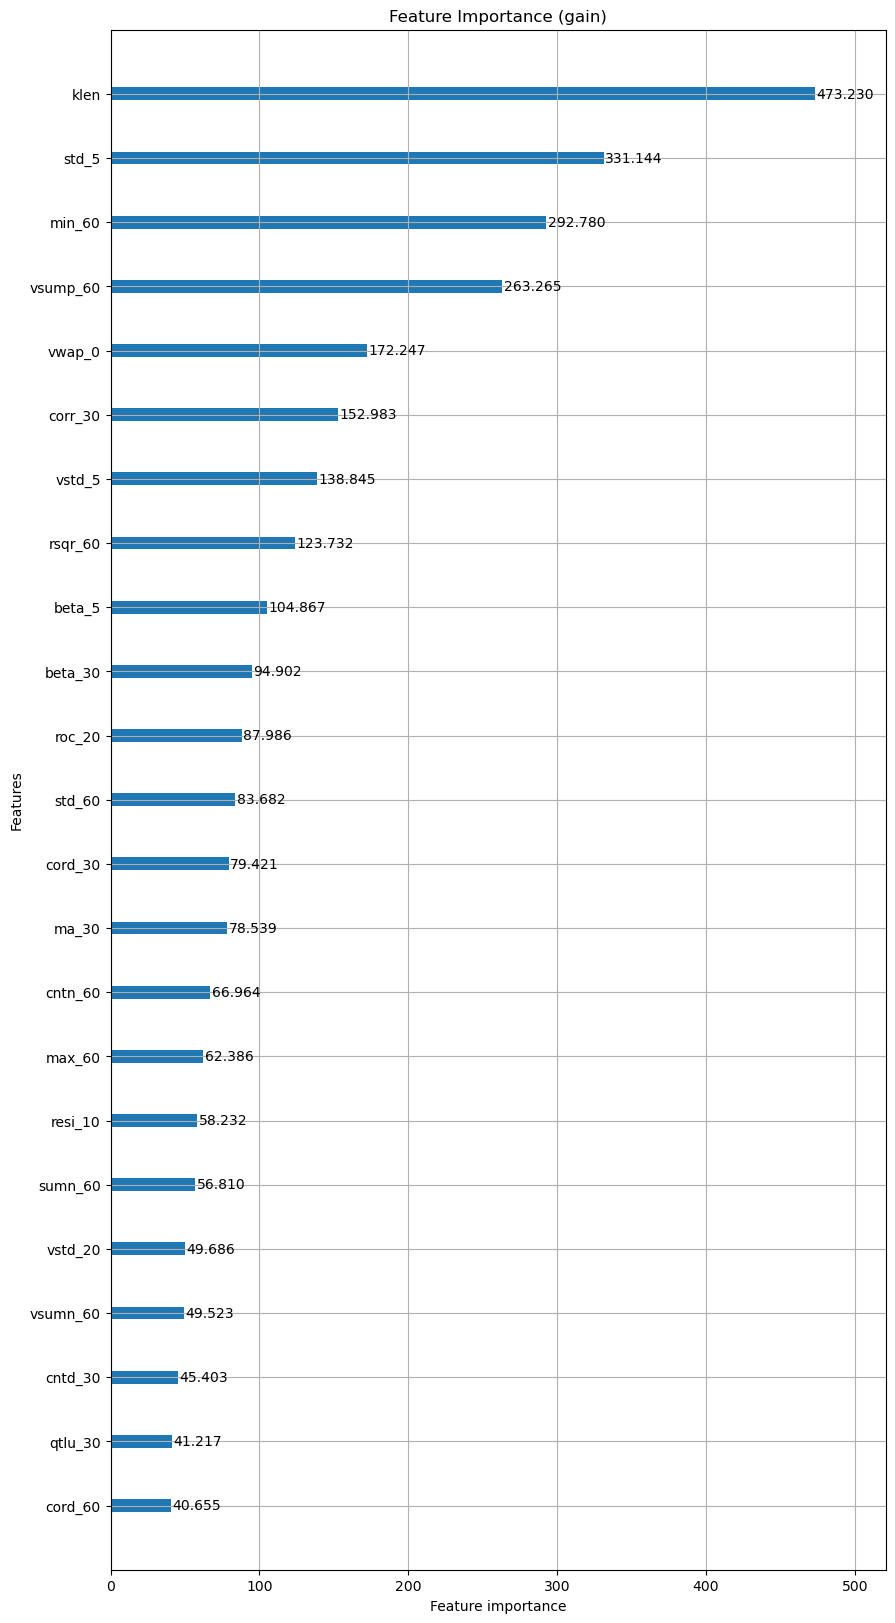

In [21]:
# 查看模型细节
model.detail()

In [22]:
# 保存模型
lab.save_model(name, model)

# 预测信号

In [23]:
model: AlphaModel = lab.load_model(name)

In [24]:
# 用模型在测试集上预测
pre: np.ndarray = model.predict(dataset, Segment.TEST)

# 加载测试集数据
df_t: pl.DataFrame = dataset.fetch_infer(Segment.TEST)

# 合并预测信号列
df_t = df_t.with_columns(pl.Series(pre).alias("signal"))

# 提取信号数据
signal: pl.DataFrame = df_t["datetime", "vt_symbol", "signal"]

In [25]:
# 检查信号绩效
dataset.show_signal_performance(signal)

Dropped 100.0% entries from factor data: 1.6% in forward returns computation and 98.4% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 100.0%, not exceeded: OK!
Quantiles Statistics


,min,max,mean,std,count,count %
factor_quantile,,,,,,


ValueError: No objects to concatenate

<Figure size 640x480 with 0 Axes>

In [ ]:
# 保存信号数据
lab.save_signal(name, signal)

# 策略回测

In [27]:
# 加载模块
import importlib
from datetime import datetime

from vnpy.alpha.strategy import BacktestingEngine

import vnpy.alpha.strategy.strategies.equity_demo_strategy as equity_demo_strategy

In [28]:
# 重载策略类
importlib.reload(equity_demo_strategy)
EquityDemoStrategy = equity_demo_strategy.EquityDemoStrategy

In [ ]:
# 从文件加载信号数据
signal = lab.load_signal(name)

In [29]:
# 创建回测引擎对象
engine = BacktestingEngine(lab)

# 设置回测参数
engine.set_parameters(
    vt_symbols=component_symbols,
    interval=Interval.DAILY,
    start=datetime(2023, 1, 1),
    end=datetime(2025, 8, 1),
    capital=100000000
)

# 添加策略实例
setting = {"top_k": 100, "n_drop": 3, "hold_thresh": 3}
engine.add_strategy(EquityDemoStrategy, setting, signal)

In [30]:
# 执行回测任务
engine.load_data()
engine.run_backtesting()
engine.calculate_result()
engine.calculate_statistics()
engine.show_chart()

2025-12-13 16:24:04 开始加载历史数据


100%|██████████| 591/591 [00:03<00:00, 149.46it/s]

2025-12-13 16:24:07 部分合约历史数据为空：['600068.SSE', '600485.SSE', '002450.SZSE', '600074.SSE', '600005.SSE', '300104.SZSE']
2025-12-13 16:24:07 所有历史数据加载完成
2025-12-13 16:24:07 策略初始化完成
2025-12-13 16:24:07 开始回放历史数据


2025-12-13 16:24:09 历史数据回放结束
2025-12-13 16:24:09 开始计算逐日盯市盈亏
2025-12-13 16:24:09 逐日盯市盈亏计算完成
2025-12-13 16:24:09 开始计算策略统计指标
2025-12-13 16:24:09 ------------------------------
2025-12-13 16:24:09 首个交易日：  2023-01-03
2025-12-13 16:24:09 最后交易日：  2025-08-01
2025-12-13 16:24:09 总交易日：  625
2025-12-13 16:24:09 盈利交易日：  307
2025-12-13 16:24:09 亏损交易日：  317
2025-12-13 16:24:09 起始资金：  100,000,000.00
2025-12-13 16:24:09 结束资金：  107,882,841.04
2025-12-13 16:24:09 总收益率：  7.88%
2025-12-13 16:24:09 年化收益：  3.03%
2025-12-13 16:24:09 最大回撤:   -24,420,160.92
2025-12-13 16:24:09 百分比最大回撤: -22.58%
2025-12-13 16:24:09 最长回撤天数:   301
2025-12-13 16:24:09 总盈亏：  7,882,841.04
2025-12-13 16:24:09 总手续费：  1,251,252.29
2025-12-13 16:24:09 总成交金额：  1,701,199,858.69
2025-12-13 16:24:09 总成交笔数：  3644
2025-12-13 16:24:09 日均盈亏：  12,612.55
2025-12-13 16:24:09 日均手续费：  2,002.00
2025-12-13 16:24:09 日均成交金额：  2,721,919.77
2025-12-13 16:24:09 日均成交笔数：  5.8304
2025-12-13 16:24:09 日均收益率：  0.02%
2025-12-13 16:24:09 收益标准差：  1.10%
2025-12-13 16

In [31]:
# 显示超额收益分析结果
engine.show_performance(benchmark_symbol=index_symbol)